In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import json
import os
from tqdm import tqdm
import pandas as pd

# Import and load sBERT embeddings

In [25]:
def load_embeddings(path):
    embeddings_dict = {
        'sentences': [],
        'embeddings': []
    }
    
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            embeddings_dict['sentences'].append(data['sentence'])
            embeddings_dict['embeddings'].append(np.array(data['embedding']))
            
    # Convert list of embeddings to a numpy array
    embeddings_dict['embeddings'] = np.array(embeddings_dict['embeddings'])
    return embeddings_dict


sbert_embeddings = {
    "Human":{
        "dolly_train_1": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_1_human_embeddings.jsonl"),
        "dolly_train_2": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_2_human_embeddings.jsonl"),
        "dolly_train_3": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_3_human_embeddings.jsonl"),
        "dolly_train_4": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_4_human_embeddings.jsonl")
    },
    "Small":{
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_1_Llama_embeddings.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_2_Llama_embeddings.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_3_Llama_embeddings.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_4_Llama_embeddings.jsonl"),
        "dolly_train_2_Gemma": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_2_Gemma_embeddings.jsonl"),
        "dolly_train_3_Qwen":  load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_3_Qwen2_embeddings.jsonl"),
        "dolly_train_4_Falcon": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_4_Falcon3-10B-Instruct_embeddings.jsonl")
    },
    "Medium":{
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_1_Llama_embeddings.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_2_Llama_embeddings.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_3_Llama_embeddings.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_4_Llama_embeddings.jsonl"),
        "dolly_train_2_Mistral": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_2_Mistral_embeddings.jsonl"),
        "dolly_train_3_Qwen": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_3_Qwen_embeddings.jsonl"),
        "dolly_train_4_Command": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_4_Command_embeddings.jsonl")
    },
    "Large": {
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_1_Llama_embeddings.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_2_Llama_embeddings.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_3_Llama_embeddings.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_4_Llama_embeddings.jsonl"),
        "dolly_train_2_Gemini": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_2_Gemini_embeddings.jsonl"),
        "dolly_train_3_GPT": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_3_GPT_embeddings.jsonl"),
        "dolly_train_4_Deepseek": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_4_Deepseek_embeddings.jsonl")
    }
}


# Calculate and plot human t-SNE embeddings

### Calculate

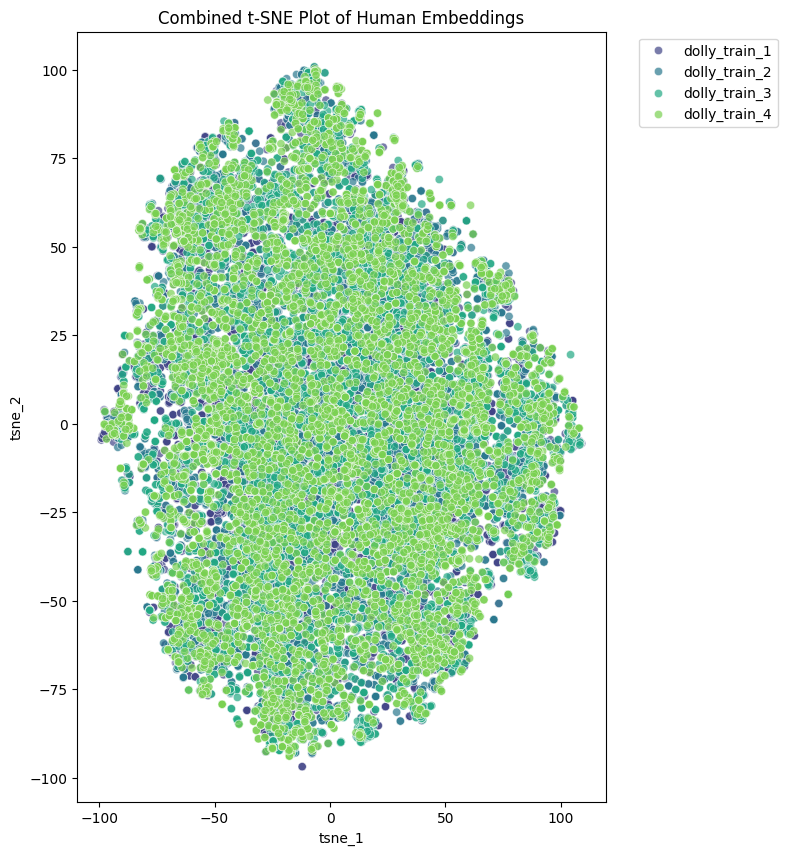

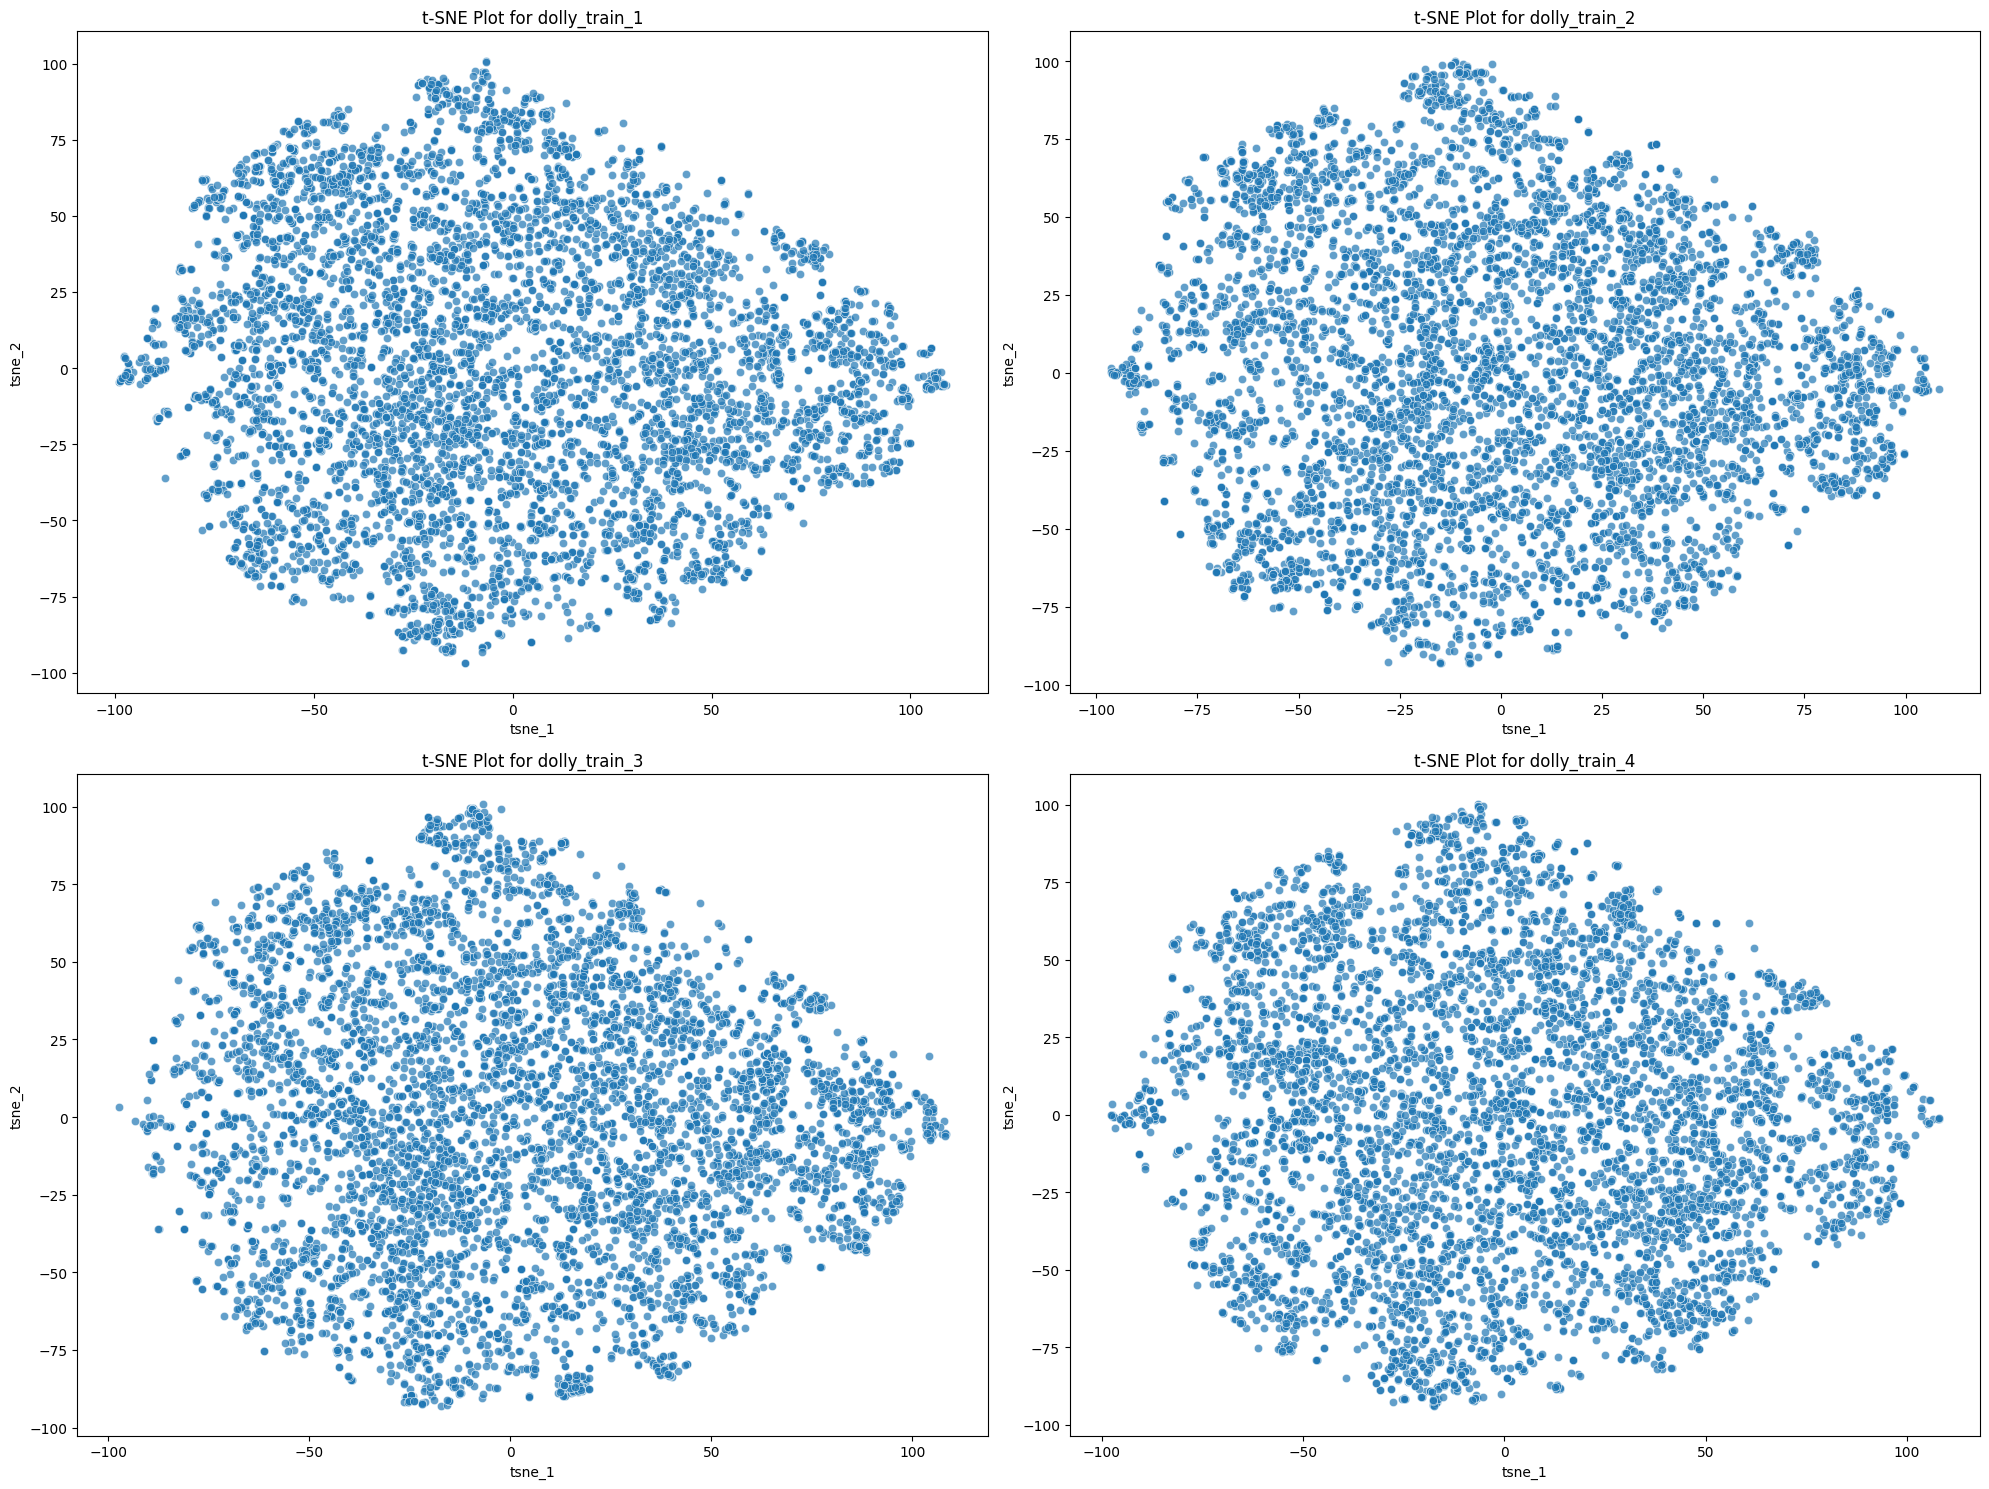

'\n# Save the t-SNE embeddings\noutput_path = "../../Data/analysis/tsne_embeddings/human_combined_tsne.jsonl"\nos.makedirs(os.path.dirname(output_path), exist_ok=True)\n\nwith open(output_path, \'w\') as f:\n    for i, (sentence, embedding, source) in enumerate(zip(human_sentences_list, human_tsne_embeddings, human_sources_list)):\n        data = {\n            \'sentence\': sentence,\n            \'tsne_embedding\': embedding.tolist(),\n            \'source\': source\n        }\n        f.write(json.dumps(data) + \'\n\')\n'

In [ ]:
# Initialize t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)

# Combine all human SBERT embeddings
human_embeddings_list = []
human_sentences_list = []
human_sources_list = []

# Collect all human embeddings
for dataset_name, dataset in sbert_embeddings["Human"].items():
    human_embeddings_list.append(dataset["embeddings"])
    human_sentences_list.extend(dataset["sentences"])
    # Create source labels for each embedding
    human_sources_list.extend([dataset_name] * len(dataset["sentences"]))

# Stack all embeddings
combined_human_embeddings = np.vstack(human_embeddings_list)

# Apply t-SNE transformation
human_tsne_embeddings = tsne.fit_transform(combined_human_embeddings)





### Plot

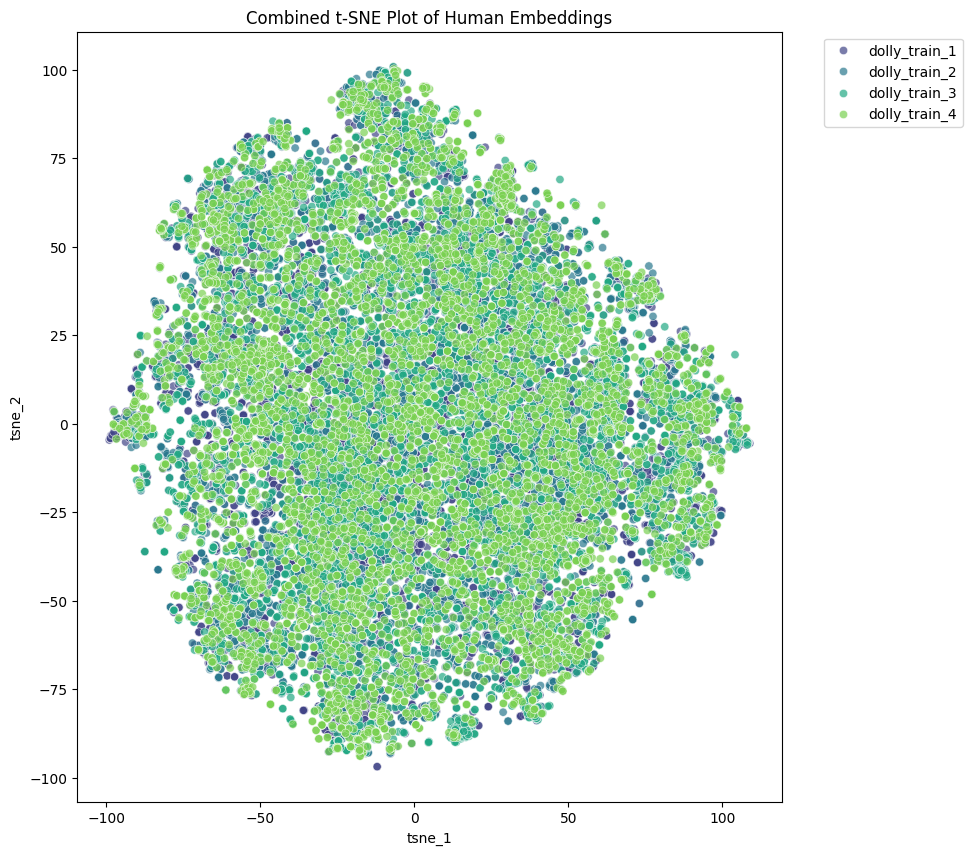

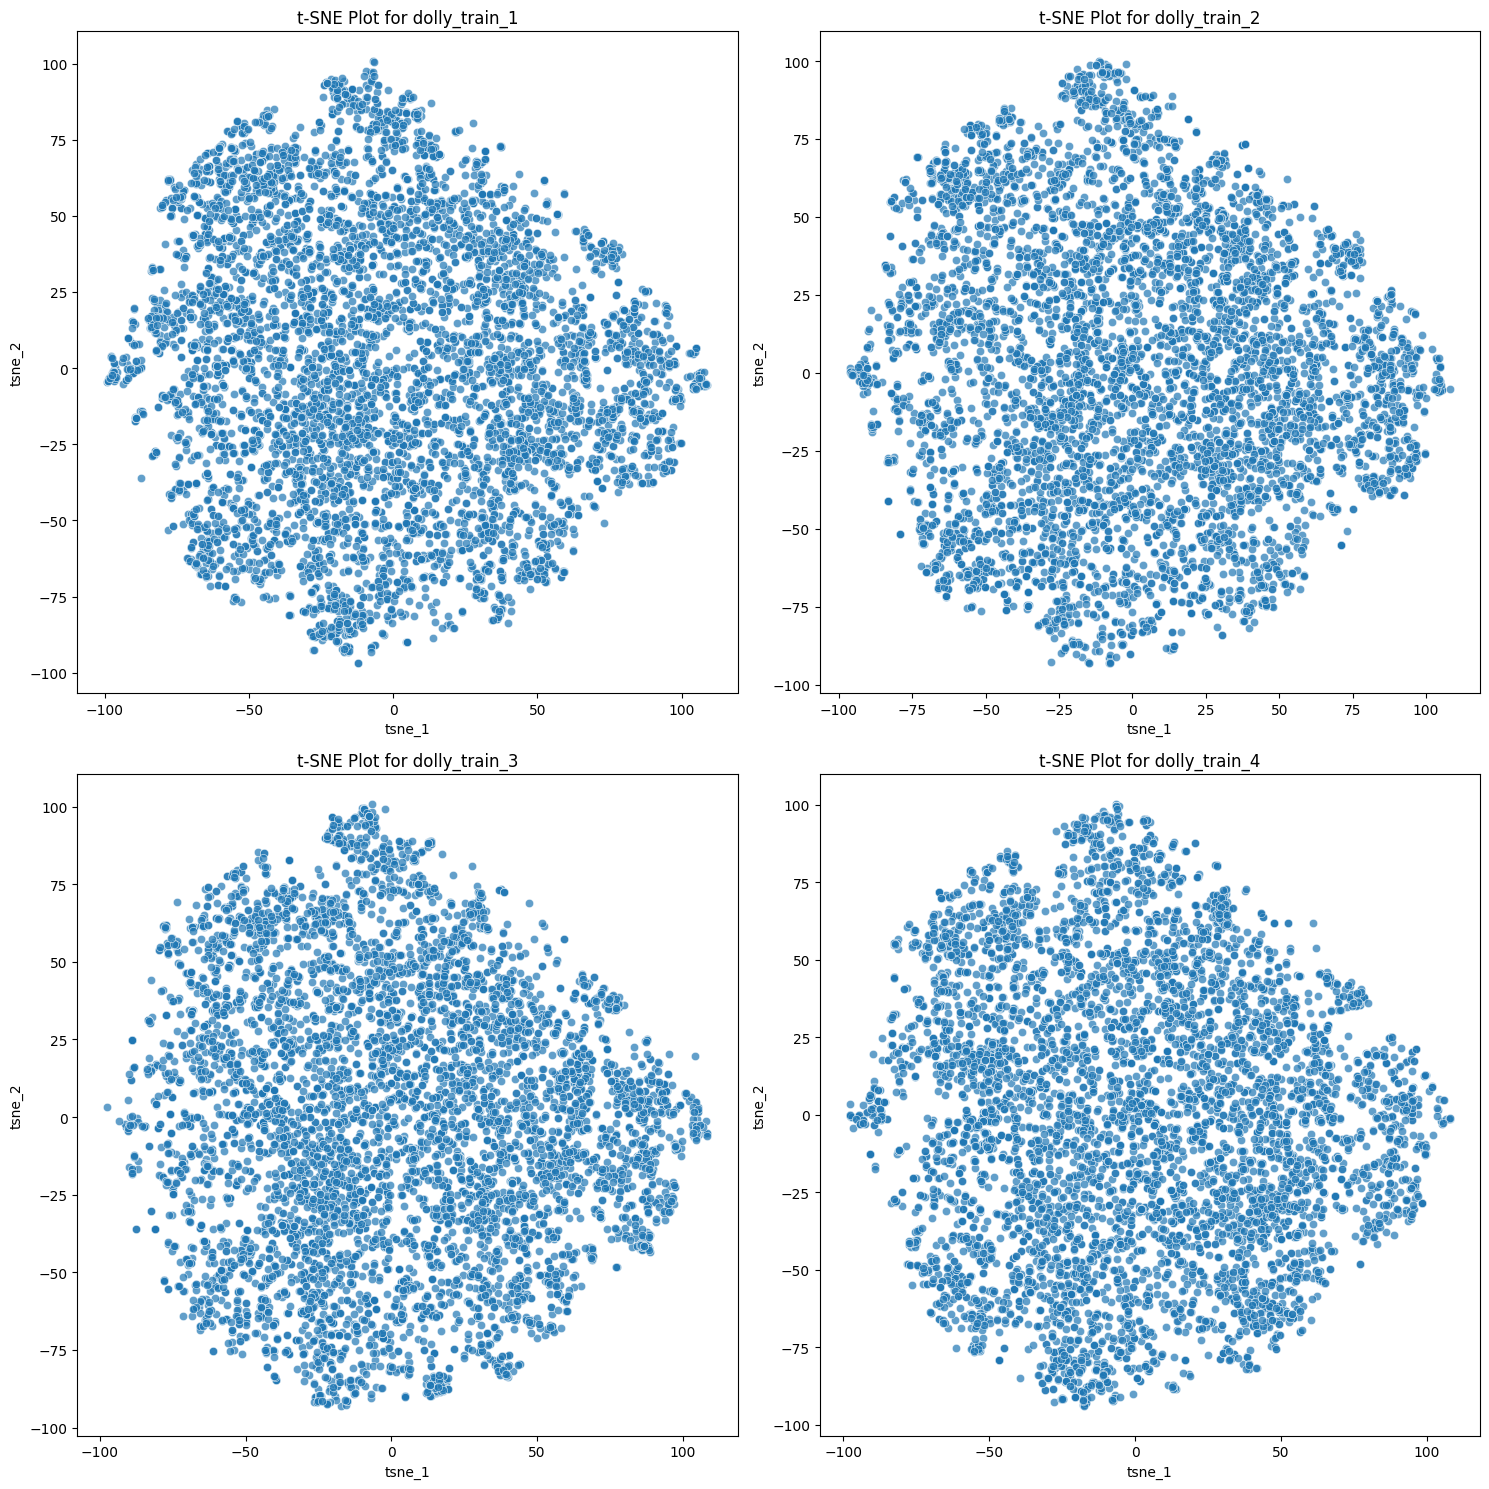

'\n# Save the t-SNE embeddings\noutput_path = "../../Data/analysis/tsne_embeddings/human_combined_tsne.jsonl"\nos.makedirs(os.path.dirname(output_path), exist_ok=True)\n\nwith open(output_path, \'w\') as f:\n    for i, (sentence, embedding, source) in enumerate(zip(human_sentences_list, human_tsne_embeddings, human_sources_list)):\n        data = {\n            \'sentence\': sentence,\n            \'tsne_embedding\': embedding.tolist(),\n            \'source\': source\n        }\n        f.write(json.dumps(data) + \'\n\')\n'

In [13]:
human_df = pd.DataFrame({
    'tsne_1': human_tsne_embeddings[:, 0],
    'tsne_2': human_tsne_embeddings[:, 1],
    'source': human_sources_list,
    'sentence': human_sentences_list
})

# Set up the figure size
plt.figure(figsize=(20, 10))

# Combined plot
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='tsne_1', 
    y='tsne_2', 
    hue='source', 
    data=human_df,
    palette='viridis',
    alpha=0.7
)
plt.title('Combined t-SNE Plot of Human Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Separate plots
plt.figure(figsize=(15, 15))
sources = human_df['source'].unique()
num_sources = len(sources)
rows = 2

for i, source in enumerate(sources):
    plt.subplot(rows, 2, i+1)
    source_data = human_df[human_df['source'] == source]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        data=source_data,
        alpha=0.7
    )
    plt.title(f't-SNE Plot for {source}')
    plt.tight_layout()

plt.show()

'''
# Save the t-SNE embeddings
output_path = "../../Data/analysis/tsne_embeddings/human_combined_tsne.jsonl"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w') as f:
    for i, (sentence, embedding, source) in enumerate(zip(human_sentences_list, human_tsne_embeddings, human_sources_list)):
        data = {
            'sentence': sentence,
            'tsne_embedding': embedding.tolist(),
            'source': source
        }
        f.write(json.dumps(data) + '\n')
'''

# Calculate and plot dual comparisons of t-SNE embeddings

## Calculate

In [43]:
# Settings
size1 = "Medium"  # Can be "Small", "Medium", "Large", "Human"
model1 = "dolly_train_4_Command"   # e.g., "dolly_train_1_Llama"

size2 = "Large"  # Can be "Small", "Medium", "Large", "Human"
model2 = "dolly_train_4_Deepseek"  # e.g., "dolly_train_1_Llama"



# Initialize t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)

# Function to get embeddings for a specific size and model
def get_embeddings_for_comparison(size, model):
    embeddings_list = []
    sentences_list = []
    sources_list = []
    
    if size in sbert_embeddings:
        if model in sbert_embeddings[size]:
            dataset = sbert_embeddings[size][model]
            embeddings_list.append(dataset["embeddings"])
            sentences_list.extend(dataset["sentences"])
            sources_list.extend([f"{size}_{model}"] * len(dataset["sentences"]))
    
    return embeddings_list, sentences_list, sources_list

# Get embeddings for first dataset
embeddings_list1, sentences_list1, sources_list1 = [], [], []

if model1 == "all" and size1 in sbert_embeddings:
    # Get all models for this size
    for dataset_name, dataset in sbert_embeddings[size1].items():
        embeddings_list1.append(dataset["embeddings"])
        sentences_list1.extend(dataset["sentences"])
        sources_list1.extend([f"{size1}_{dataset_name}"] * len(dataset["sentences"]))
else:
    embeddings_list1, sentences_list1, sources_list1 = get_embeddings_for_comparison(size1, model1)

# Get embeddings for second dataset
embeddings_list2, sentences_list2, sources_list2 = get_embeddings_for_comparison(size2, model2)

# Combine both datasets
combined_embeddings_list = embeddings_list1 + embeddings_list2
combined_sentences_list = sentences_list1 + sentences_list2
combined_sources_list = sources_list1 + sources_list2

# Stack all embeddings
if combined_embeddings_list:
    combined_embeddings = np.vstack(combined_embeddings_list)
    
    # Apply t-SNE transformation
    combined_tsne_embeddings = tsne.fit_transform(combined_embeddings)
else:
    print("No embeddings found for the specified size and model combinations.")
    combined_tsne_embeddings = np.array([])
    


## Plot

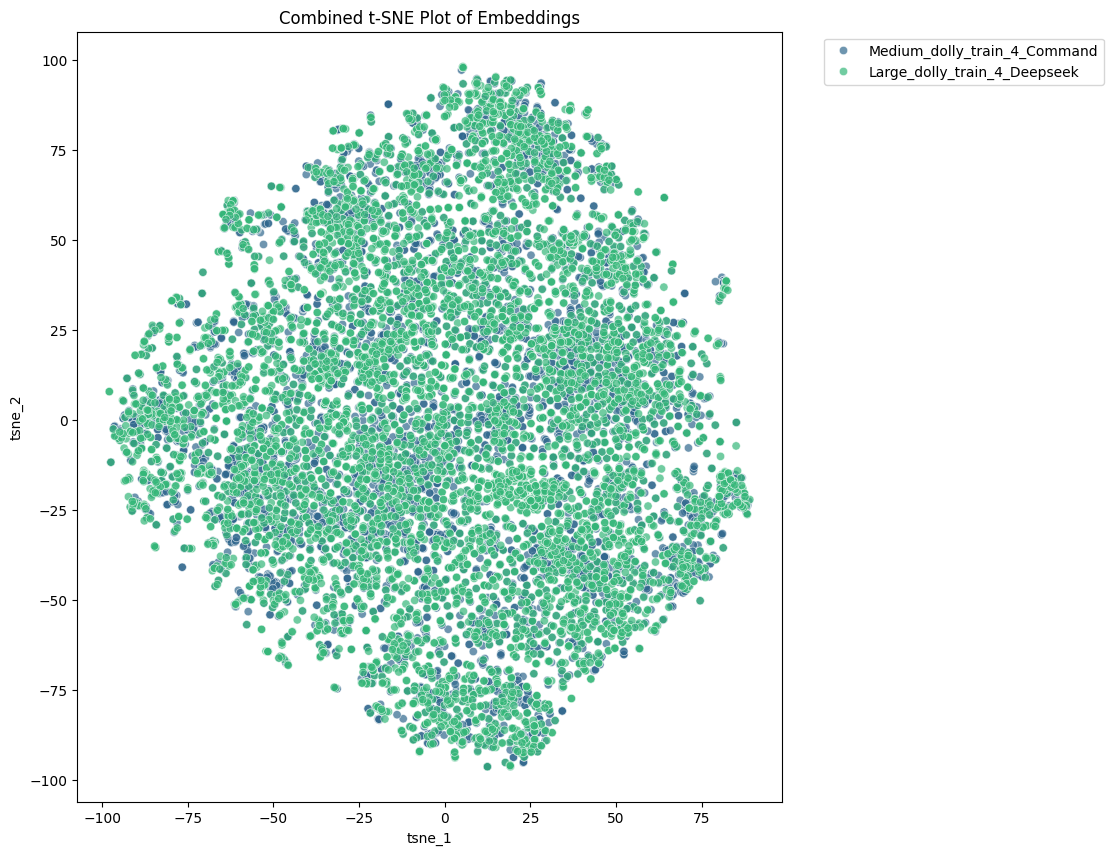

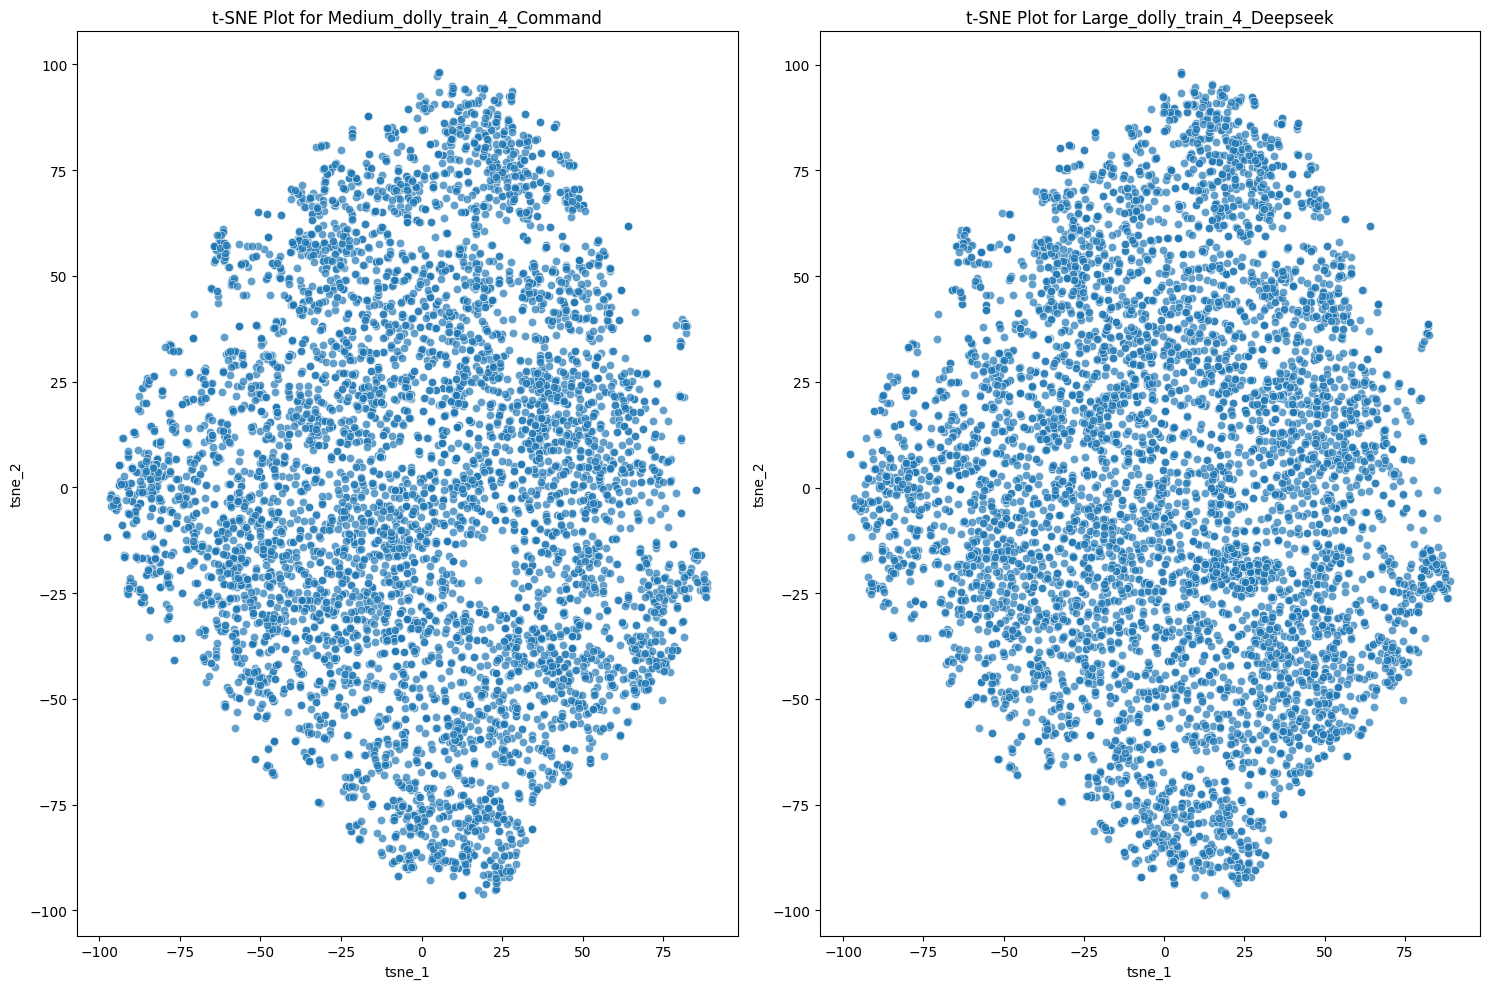

In [44]:
combined_df = pd.DataFrame({
    'tsne_1': combined_tsne_embeddings[:, 0],
    'tsne_2': combined_tsne_embeddings[:, 1],
    'source': combined_sources_list,
    'sentence': combined_sentences_list
})

# Set up the figure size
plt.figure(figsize=(20, 10))

# Combined plot
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='tsne_1', 
    y='tsne_2', 
    hue='source', 
    data=combined_df,
    palette='viridis',
    alpha=0.7
)
plt.title('Combined t-SNE Plot of Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Separate plots
plt.figure(figsize=(15, 10))
sources = combined_df['source'].unique()
num_sources = len(sources)
rows = (num_sources + 1) // 2  # Calculate rows needed for all sources

for i, source in enumerate(sources):
    plt.subplot(rows, 2, i+1)
    source_data = combined_df[combined_df['source'] == source]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        data=source_data,
        alpha=0.7
    )
    plt.title(f't-SNE Plot for {source}')
    plt.tight_layout()

plt.show()



## Save

In [45]:
# Save the plots
output_dir = "../../Plots/tsne_plots"
os.makedirs(output_dir, exist_ok=True)

# Save the combined plot
plt.figure(figsize=(10, 10))
sns.scatterplot(
    x='tsne_1', 
    y='tsne_2', 
    hue='source', 
    data=combined_df,
    palette='viridis',
    alpha=0.7
)
plt.title('Combined t-SNE Plot of Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{output_dir}/{model1}_{size1}_vs_{model2}_{size2}_combined.png", dpi=300)
plt.close()

# Save the individual plots
fig, axes = plt.subplots(rows, 2, figsize=(15, 10))
fig.suptitle(f't-SNE Plots by Source: {model1}_{size1} vs {model2}_{size2}')

for i, source in enumerate(sources):
    row, col = i // 2, i % 2
    if rows > 1:
        ax = axes[row, col]
    else:
        ax = axes[col]
    
    source_data = combined_df[combined_df['source'] == source]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        data=source_data,
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f't-SNE Plot for {source}')

plt.tight_layout()
plt.savefig(f"{output_dir}/{model1}_{size1}_vs_{model2}_{size2}_separate.png", dpi=300)
plt.close()

print(f"Plots saved to {output_dir}")


Plots saved to ../../Plots/tsne_plots


In [46]:
# Save the t-SNE embeddings
output_path = f"../../Data/analysis/tsne_embeddings/combined/{model1}_{size1}_vs_{model2}_{size2}.jsonl"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w') as f:
    for i, (sentence, embedding, source) in enumerate(zip(combined_sentences_list, combined_tsne_embeddings, combined_sources_list)):
        data = {
            'sentence': sentence,
            'tsne_embedding': embedding.tolist(),
            'source': source
        }
        f.write(json.dumps(data) + '\n')
